# Heterogeneity Review

This notebook presents the repeated-split heterogeneity results: the BLP test, sorted GATEs, CLAN summary, and permutation-adjusted importance.

## Outputs Produced By This Notebook

This notebook runs the repeated-split heterogeneity script and writes the final summary outputs to `outputs/heterogeneity_results/`.

Key saved files are:
- `repeated_split_blp_summary.csv`
- `repeated_split_sorted_gate_summary.csv`
- `repeated_split_sorted_gate_plot.png`
- `repeated_split_clan_summary.csv`
- `repeated_split_clan_table.csv`
- `repeated_split_settings.csv`
- `permutation_importance_summary.csv`
- `permutation_importance_plot.png`

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 180
mpl.rcParams['savefig.dpi'] = 300

from pathlib import Path
import importlib.util

_cwd = Path.cwd().resolve()
_cands = [_cwd, _cwd.parent]
PROJECT_ROOT = next((p for p in _cands if (p / "MODELS" / "03_heterogeneity_analysis.py").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root")

MODELS_DIR = PROJECT_ROOT / "MODELS"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
HETERO_DIR = OUTPUT_DIR / "heterogeneity_results"

def load_module(module_filename: str, module_name: str):
    module_path = MODELS_DIR / module_filename
    spec = importlib.util.spec_from_file_location(module_name, module_path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not load {module_path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

heterogeneity_module = load_module("03_heterogeneity_analysis.py", "heterogeneity_analysis")
PROJECT_ROOT.relative_to(PROJECT_ROOT.parent)


PosixPath('D300 real')

## Run The Heterogeneity Script

The script below generates the repeated-split heterogeneity results used in this notebook.

In [2]:
import os

os.environ.setdefault("HET_N_SPLITS", "100")
os.environ.setdefault("HET_CF_TREES", "400")
os.environ.setdefault("HET_N_PERM", "50")
os.environ.setdefault("HET_PERM_CF_TREES", "200")
heterogeneity_module.main()


Saved heterogeneity outputs to: outputs/heterogeneity_results


0

## 1. Repeated-Split Formal Inference

These outputs summarize the formal repeated-split heterogeneity results.


### BLP Summary

This table reports the repeated-split BLP-style omnibus heterogeneity test. The key quantity is whether the heterogeneity term remains clearly above zero across splits.


In [3]:
import pandas as pd
pd.read_csv(HETERO_DIR / "repeated_split_blp_summary.csv")


,term,estimate_median,ci95_low_median,ci95_high_median,n_splits
0,ATE_beta1,-0.023649,-0.028778,-0.018494,100
1,HET_beta2,0.670323,0.332557,1.001154,100


### Repeated-Split Sorted GATE

This table summarizes how the estimated treatment effect changes across effect-sorted groups under repeated sample splitting. The figure underneath gives the same result in a more visual form.


In [4]:
pd.read_csv(HETERO_DIR / "repeated_split_sorted_gate_summary.csv")


,group,tau_mean,ci95_low,ci95_high,n_obs
0,Q1,-0.043566,-0.056274,-0.031090,2997.0
1,Q2,-0.022976,-0.033392,-0.012427,2996.0
2,Q3,-0.012154,-0.020775,-0.003679,2996.0
3,Q4,-0.016750,-0.025222,-0.007835,2997.0
4,Q4_minus_Q1,0.026688,0.011344,0.041864,5994.0


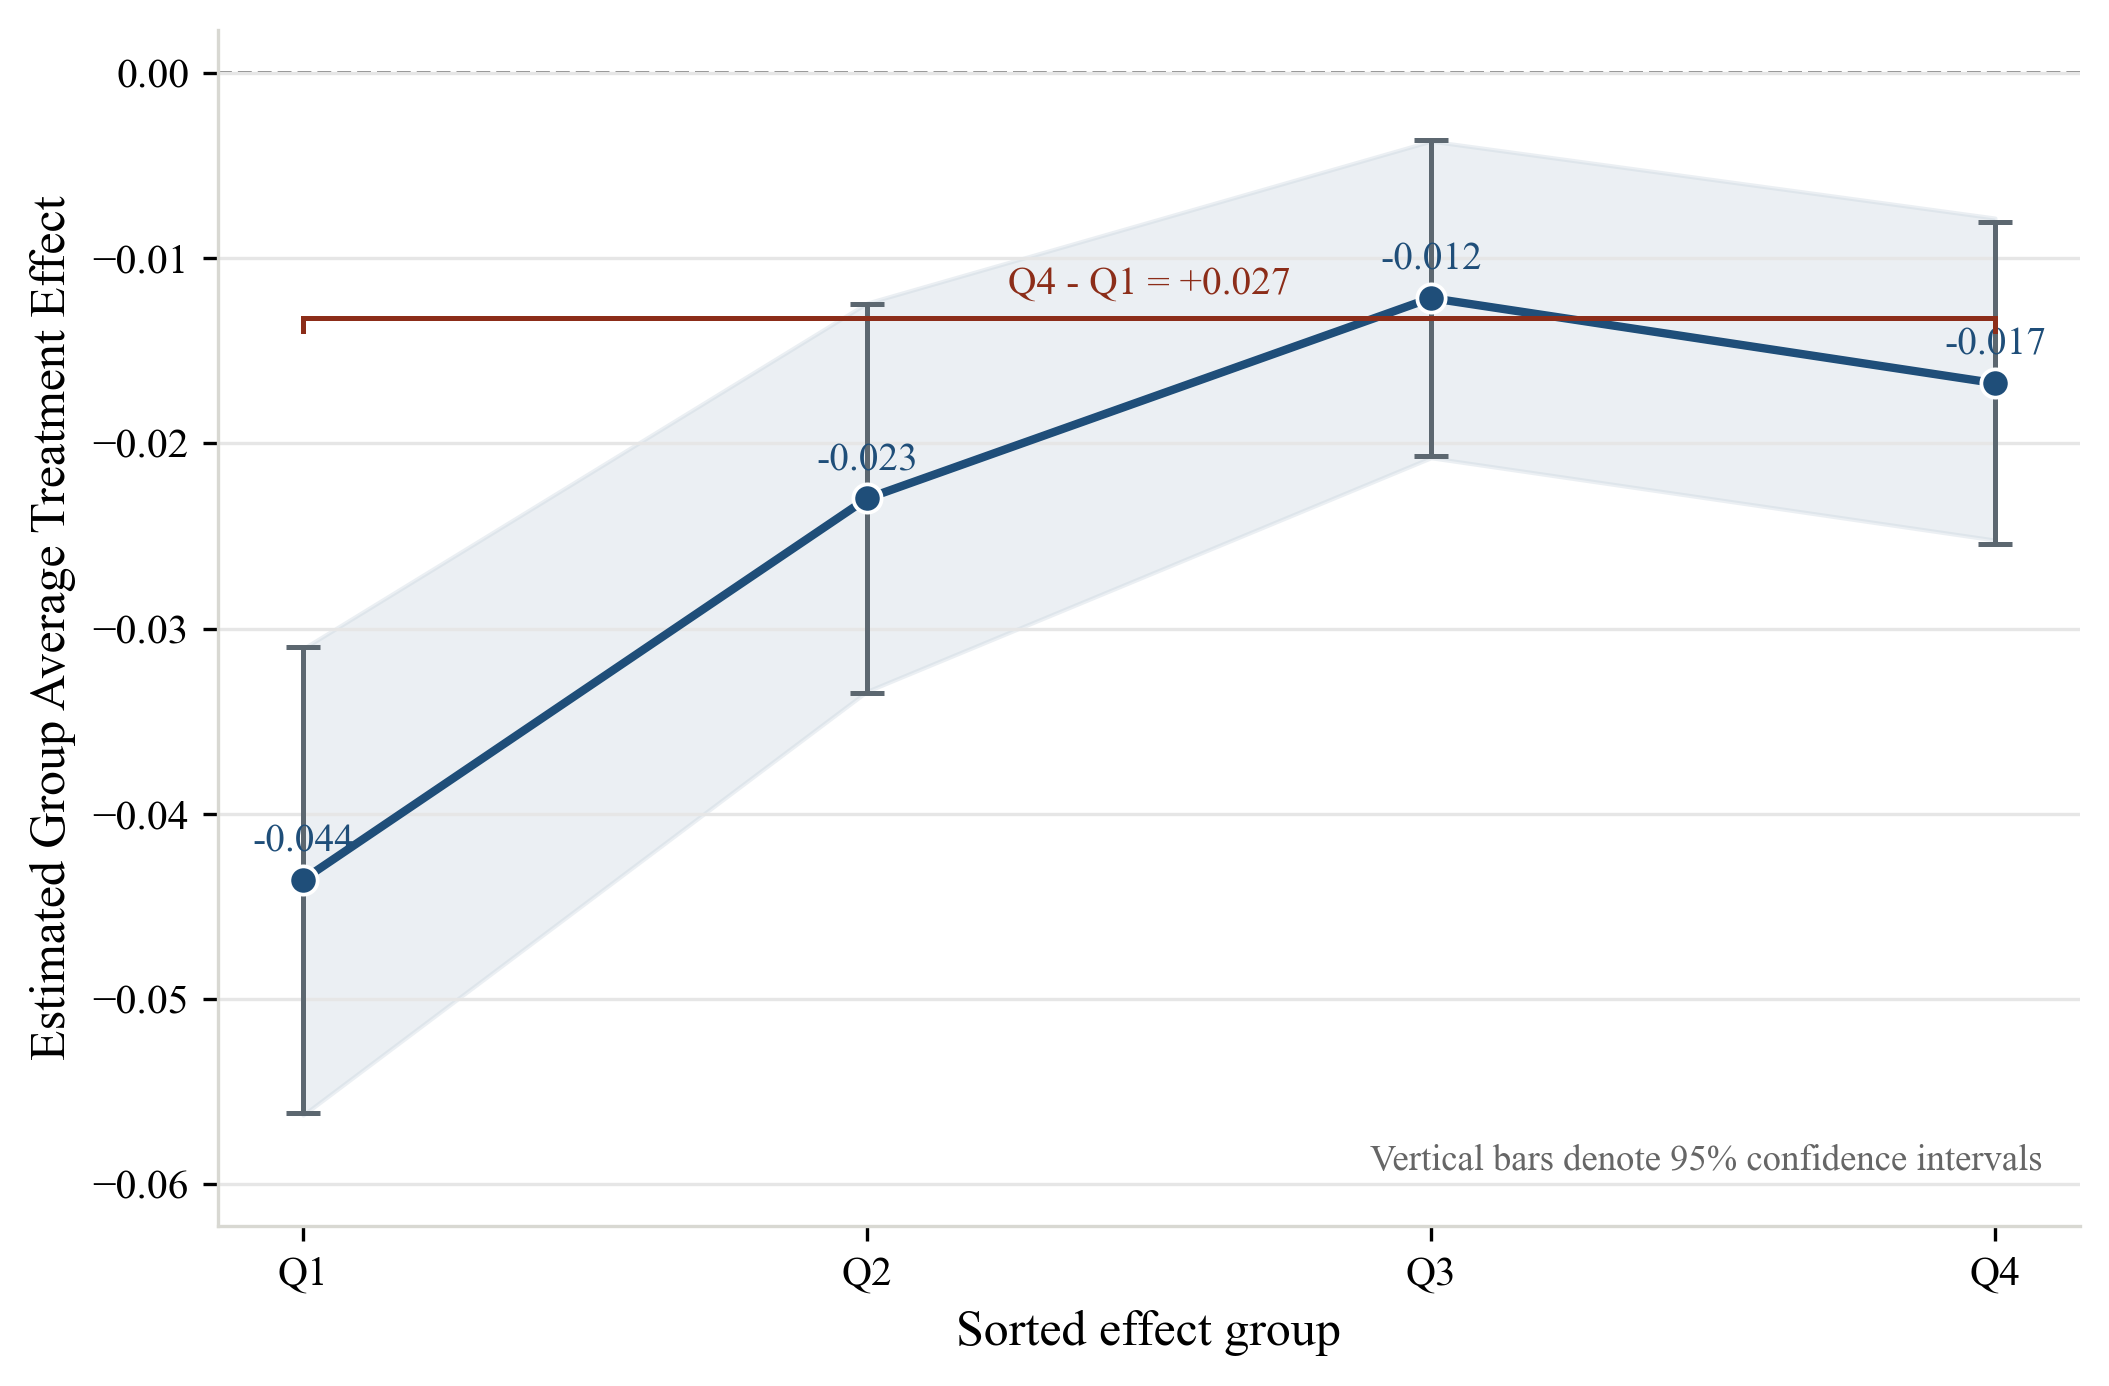

In [5]:
from IPython.display import Image, display
display(Image(filename=str(HETERO_DIR / "repeated_split_sorted_gate_plot.png")))


### Repeated-Split CLAN

This is the main group-characterization table. It compares the most affected group (Q1) with the least affected group (Q4) using the repeated-split summary, so it is the version that should be cited in the report.

In [6]:
pd.read_csv(HETERO_DIR / "repeated_split_clan_table.csv")

,Characteristic,Most affected (Q1),Least affected (Q4),Difference (Q4 - Q1),95% CI for difference
0,Food share,0.441,0.320,-0.119,"[-0.127, -0.111]"
1,Log total expenditure,12.864,13.930,1.067,"[1.037, 1.096]"
2,Age,63.233,45.440,-17.493,"[-18.117, -16.889]"
3,Household size,2.276,4.677,2.405,"[2.336, 2.474]"
4,Male share,0.710,0.954,0.242,"[0.225, 0.260]"
5,Propensity score,0.453,0.597,0.144,"[0.138, 0.150]"


### Permutation-Adjusted Importance

This table reports the permutation-based importance exercise, which is more conservative than raw forest importance. The plot underneath makes the relative magnitudes easier to compare.


In [7]:
pd.read_csv(HETERO_DIR / "permutation_importance_summary.csv")


,feature,observed_importance,perm_median,perm_p95,perm_p_value,adjusted_importance,n_permutations
0,log_totexp,0.581002,0.630550,0.655070,1.000000,-0.000000,50
1,age,0.307622,0.257075,0.273915,0.019608,3.931826,50
2,size,0.080736,0.092046,0.119847,0.980392,0.019803,50
3,sex_male,0.030640,0.018979,0.025864,0.019608,3.931826,50


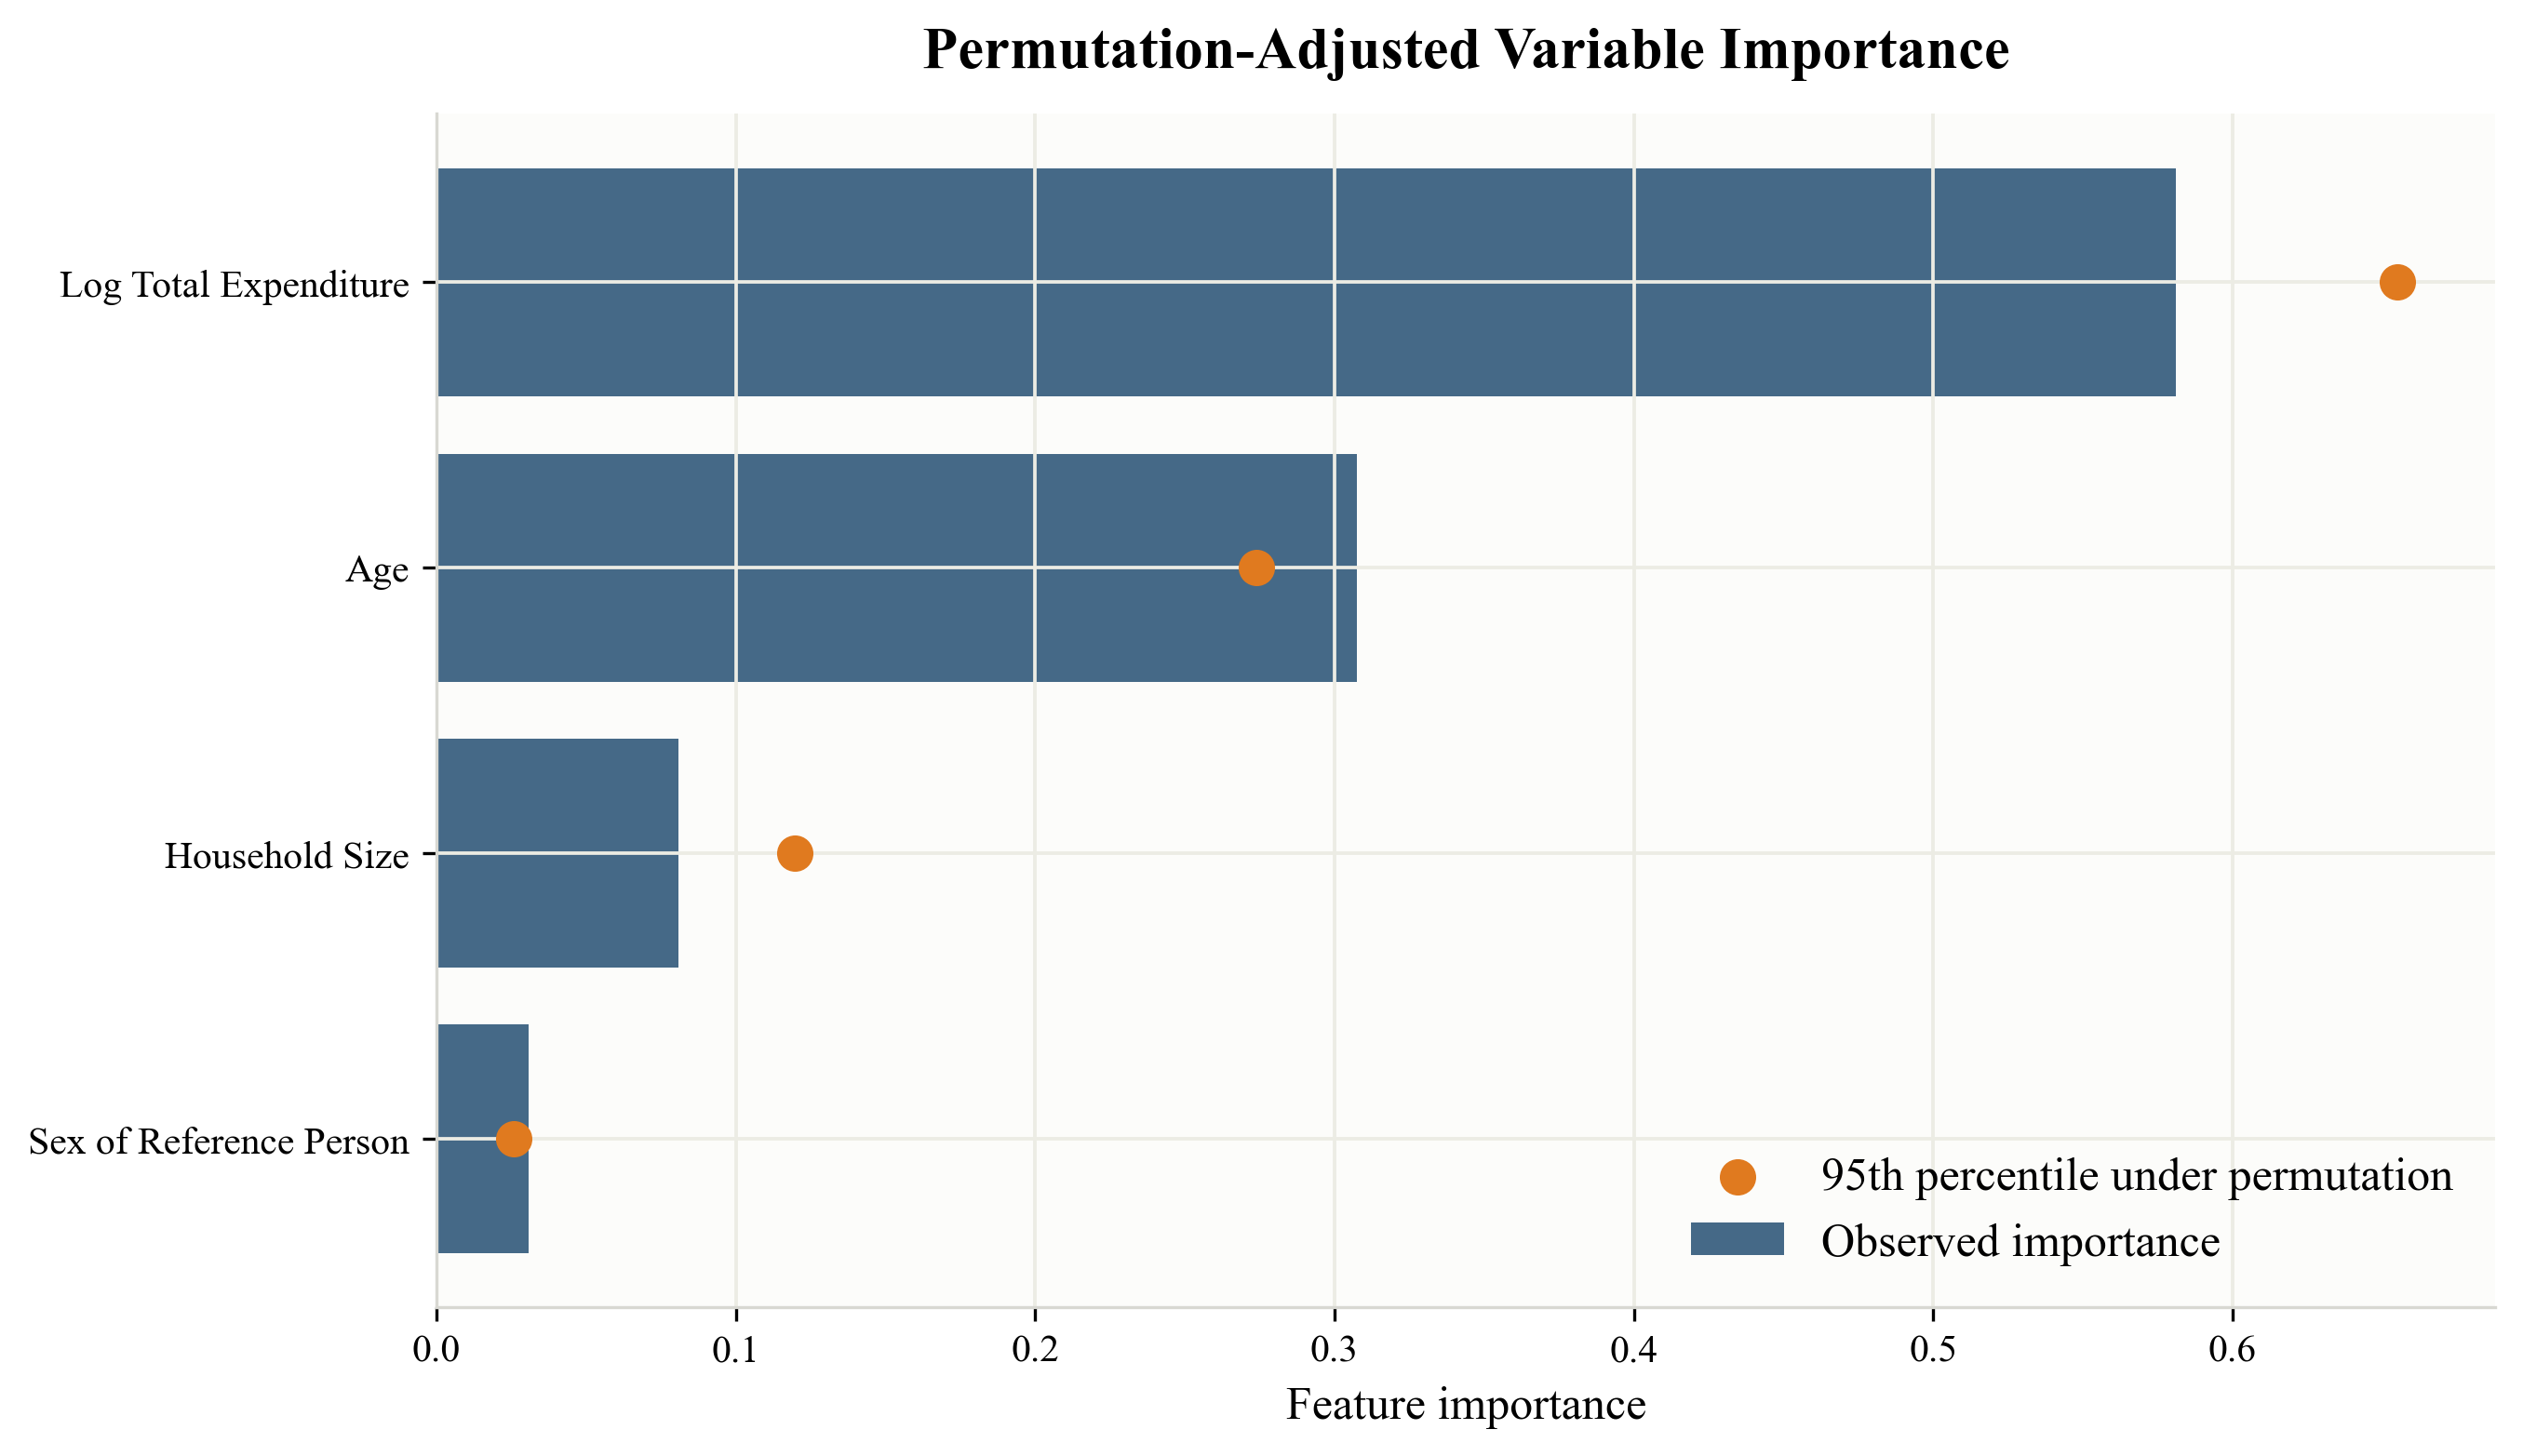

In [8]:
display(Image(filename=str(HETERO_DIR / "permutation_importance_plot.png")))


## 2. Interpreting The Repeated-Split Results

The BLP results test whether heterogeneity is present, the sorted GATE results summarize the ranked effect gap, and the CLAN table describes the most- and least-affected groups. The permutation-adjusted importance exercise is a stricter robustness check.